# CIC Trap4Phish Multi-File Phishing Detection (Refined)

This notebook analyzes phishing document features extracted from multiple file types (HTML, PDF, Word, Excel).

### Core Improvements in this Version:
1. **Data Integrity**: Global duplicate check across merged datasets to prevent inflated performance.
2. **Leakage Prevention**: Feature scaling (StandardScaler) is applied strictly *after* the train-test split.
3. **Analytical Depth**: Added Confusion Matrices and ROC-AUC evaluations.
4. **Comparison**: Formal performance comparison across document types.

In [17]:
# Standard data processing
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn for classical ML & feature selection
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, roc_auc_score, roc_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif, RFE

# TensorFlow / Keras for Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Phase 1: Data Integration & Cleaning

We merge the datasets and perform a critical check for **Duplicate Rows** which could lead to data leakage if identical samples appear in both training and testing sets.

In [18]:
# Define path to the shared drive dataset
BASE_PATH = "/content/drive/MyDrive/phishing/"

# Load individual file types
excel = pd.read_csv(BASE_PATH + "Excel_All_Features.csv")
word = pd.read_csv(BASE_PATH + "Word_All_features.csv")
pdf = pd.read_csv(BASE_PATH + "PDF_All_features.csv")
html = pd.read_csv(BASE_PATH + "HTML_All_Features.csv")

# Add file type label
excel['file_type'] = 'excel'
word['file_type'] = 'word'
pdf['file_type'] = 'pdf'
html['file_type'] = 'html'

# Combine all datasets
data = pd.concat([excel, word, pdf, html], ignore_index=True)

# 1. Global Duplicate Check
initial_count = len(data)
data.drop_duplicates(inplace=True)
dropped_count = initial_count - len(data)

# 2. Handle missing features
data.fillna(0, inplace=True)

print(f"Initial row count: {initial_count}")
print(f"Dropped duplicates: {dropped_count}")
print(f"Final dataset shape: {data.shape}")
display(data['file_type'].value_counts())

Initial row count: 79293
Dropped duplicates: 3395
Final dataset shape: (75898, 170)


,count
file_type,
excel,20000
html,19997
pdf,19296
word,16605


In [19]:
# Verify the contents of the 'phishing' folder
!ls -F /content/drive/MyDrive/phishing/

Excel_All_Features.csv	  PDF_All_features.csv	  Word_All_features.csv
Excel_Top10_Features.csv  PDF_Top10_features.csv  Word_Top10_Features.csv
HTML_All_Features.csv	  phishing@
HTML_Top13_Features.csv   Readme.txt


After adding a shortcut of the shared folder to your 'My Drive', you can use the following code to find the exact path to the folder. Look for a folder with a similar name to `1Id54AbOUHXQkbefV6XmabsNRUbMOFYt5`.

In [20]:
import os

# List contents of your My Drive to find the shortcut
# You might need to adjust the path if your shortcut is nested within other folders
!ls -F /content/drive/MyDrive

# If you find the shortcut, you can then verify its contents
# For example, if the shortcut name is '1Id54AbOUHXQkbefV6XmabsNRUbMOFYt5'
# !ls -F /content/drive/MyDrive/1Id54AbOUHXQkbefV6XmabsNRUbMOFYt5/

'Colab Notebooks'/
 DEKAE_Project/
'DEKAE_Project (1)'@
'DEKAE_Project (2)'@
'Finite Fields for Cryptography Explained.gdoc'
 FSAKE_results/
 phishing/
'phishing (1)'@
 P-NNDL1/
 projects1.rar
 projects2.rar
 projects3.rar
 projects4.rar
 projects5.rar
 projects.rar
'تحلیل کد TLS و سند راهنما.gdoc'
'تحلیل کد TLS و مستندات آن'
'تنظیمات، ارسال پیام و عیب‌یابی.gdoc'
'راهنمای استقرار سامانه پیام‌رسان Docker.gdoc'
'راهنمای استقرار سامانه پیام‌رسان با Docker (1).gdoc'
'راهنمای استقرار سامانه پیام‌رسان با Docker.gdoc'
'راهنمای یکپارچه‌سازی پخش تلویزیونی Compass.gdoc'
'مبانی حساب پیمانه‌ای و ساختارهای جبری.gdoc'
'مبانی ریاضی امنیت داده و شبکه.gdoc'


## Phase 2: Performance Comparison Across Document Types

We evaluate how well a Random Forest classifier performs on each document type in isolation.

,File Type,Accuracy,F1-Score
0,excel,1.000000,1.000000
1,word,1.000000,1.000000
2,pdf,0.998705,0.998750
3,html,0.938750,0.938303


/tmp/ipykernel_5919/1507271941.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=res_df, x='File Type', y='Accuracy', palette='magma')


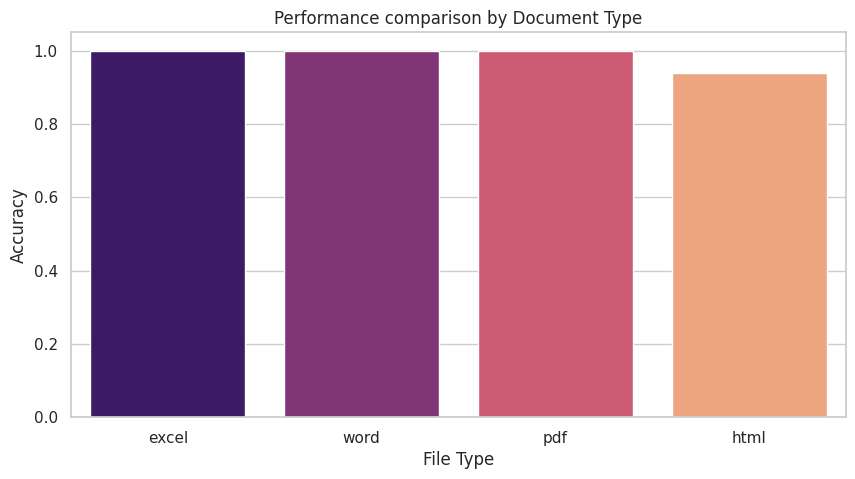

In [21]:
# Identify features (exclude label and non-numeric metadata)
numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
if 'label' in numeric_cols:
    numeric_cols.remove('label')

results_per_type = []

for ftype in data['file_type'].unique():
    subset = data[data['file_type'] == ftype]

    X_sub = subset[numeric_cols]
    y_sub = subset['label']

    X_train_sub, X_test_sub, y_train_sub, y_test_sub = train_test_split(
        X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
    )

    clf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    clf.fit(X_train_sub, y_train_sub)

    preds = clf.predict(X_test_sub)
    results_per_type.append({
        'File Type': ftype,
        'Accuracy': accuracy_score(y_test_sub, preds),
        'F1-Score': f1_score(y_test_sub, preds)
    })

# Formal Comparison Table
res_df = pd.DataFrame(results_per_type).sort_values(by='Accuracy', ascending=False)
display(res_df)

plt.figure(figsize=(10, 5))
sns.barplot(data=res_df, x='File Type', y='Accuracy', palette='magma')
plt.title('Performance comparison by Document Type')
plt.ylim(0, 1.05)
plt.show()

## Phase 3: Global Model (Preventing Data Leakage)

**Crucial Step**: We split the data into training and testing sets **before** fitting the `StandardScaler`. This ensures the test set remains completely unseen by the preprocessing parameters.

In [22]:
X = data[numeric_cols]
y = data['label']

# 1. Split first
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Scale second (Fit on train, transform both)
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train_raw), columns=X_train_raw.columns)
X_test = pd.DataFrame(scaler.transform(X_test_raw), columns=X_test_raw.columns)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (60718, 167)
X_test shape: (15180, 167)


## Phase 4: Feature Selection (MI vs RFE)

We select the top 15 features using Mutual Information and Recursive Feature Elimination to find the most efficient predictors.

In [23]:
# 1. Mutual Information
print("Calculating Mutual Information...")
mi_scores = mutual_info_classif(X_train, y_train, random_state=42)
top_15_mi_cols = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False).head(15).index.tolist()

# 2. RFE
print("Performing RFE (Recursive Feature Elimination)...")
rfe_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rfe = RFE(estimator=rfe_model, n_features_to_select=15)
rfe.fit(X_train, y_train)
top_15_rfe_cols = X_train.columns[rfe.support_].tolist()

print(f"MI Features: {top_15_mi_cols[:3]}...")
print(f"RFE Features: {top_15_rfe_cols[:3]}...")

Calculating Mutual Information...
Performing RFE (Recursive Feature Elimination)...
MI Features: ['file_size', 'entropy_of_text', 'macro_average_line_length']...
RFE Features: ['file_size', 'entropy_of_text', 'macro_chr_count']...


## Phase 5: Global Model Evaluation

We evaluate the models with the 3 different feature sets (Full, MI-15, RFE-15) and add Confusion Matrices for depth.

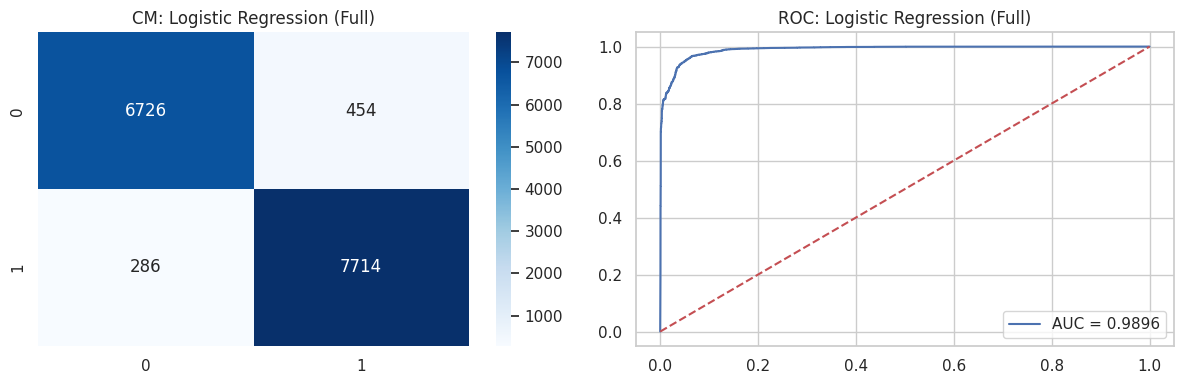

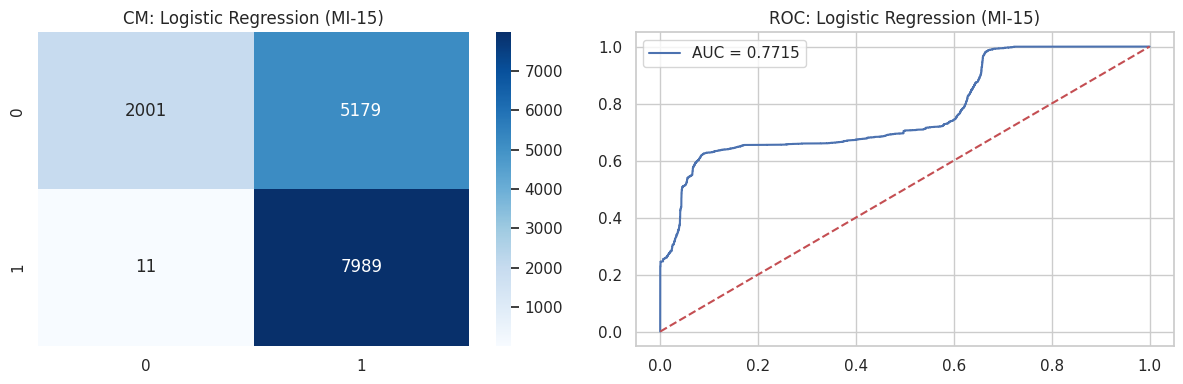

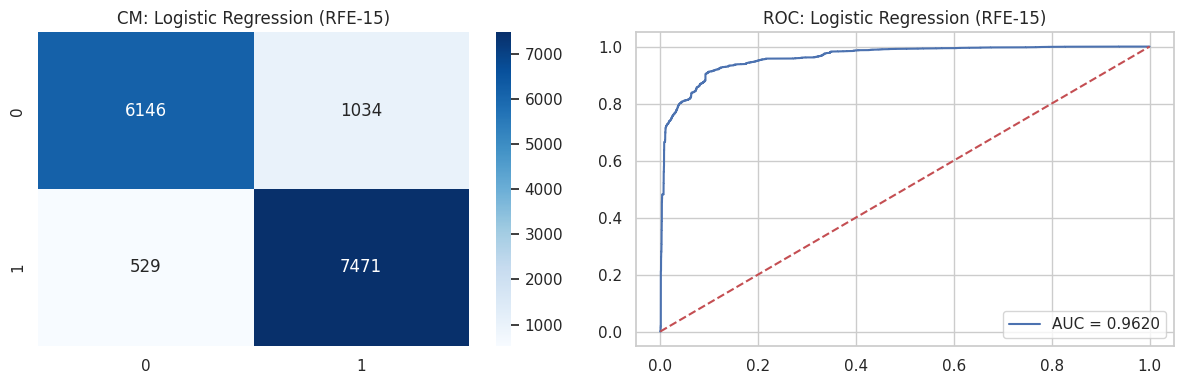

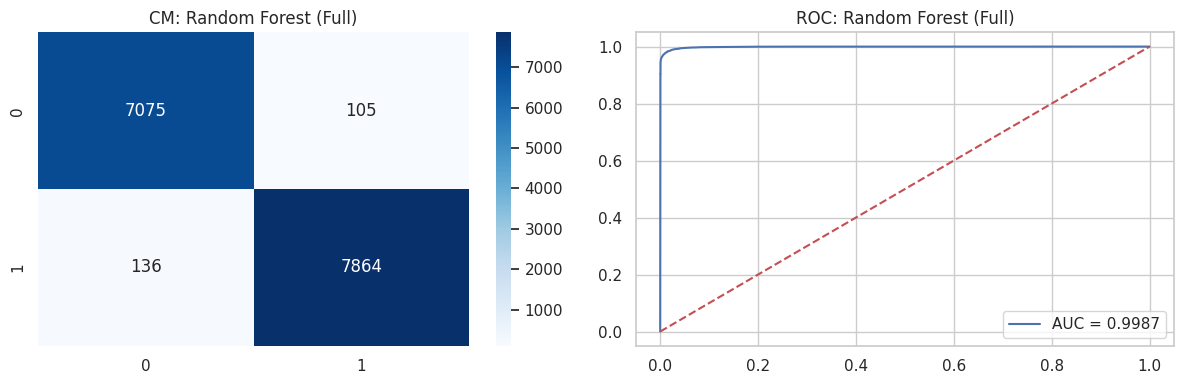

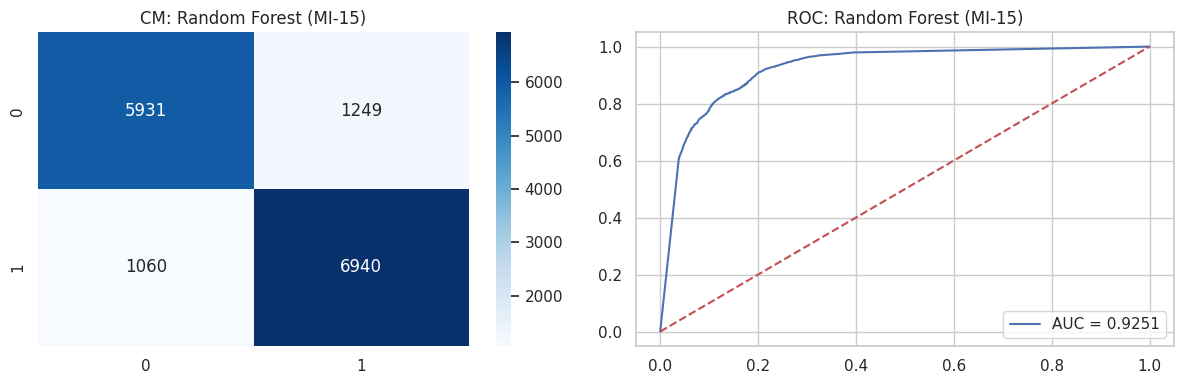

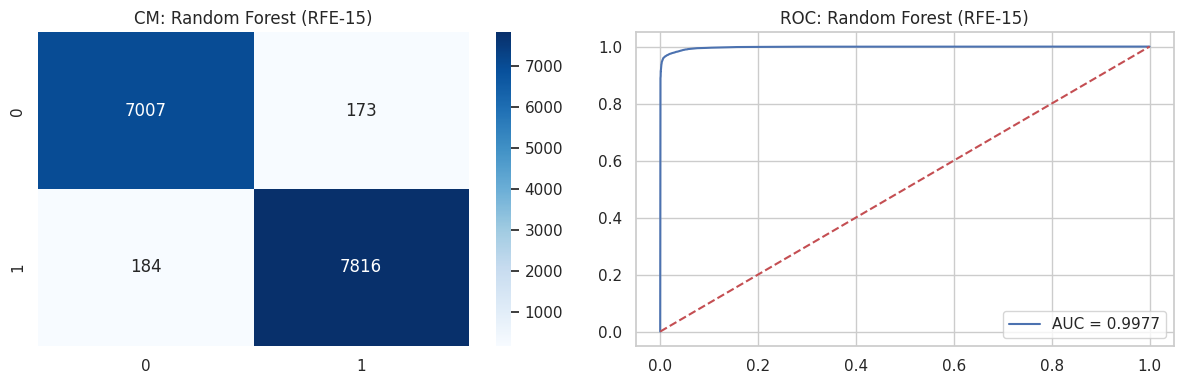

Set,Full,MI-15,RFE-15
Model,,,
Logistic Regression,0.951252,0.658103,0.897036
Random Forest,0.984124,0.847892,0.976482


In [24]:
def evaluate_model(model, xtr, xte, title):
    model.fit(xtr, y_train)
    preds = model.predict(xte)
    probs = model.predict_proba(xte)[:, 1] if hasattr(model, 'predict_proba') else preds

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    # Plotting
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1)
    ax1.set_title(f"CM: {title}")

    fpr, tpr, _ = roc_curve(y_test, probs)
    ax2.plot(fpr, tpr, label=f'AUC = {auc:.4f}')
    ax2.plot([0,1], [0,1], 'r--')
    ax2.set_title(f"ROC: {title}")
    ax2.legend()
    plt.tight_layout()
    plt.show()

    return acc, f1, auc

results = []
models = {'Logistic Regression': LogisticRegression(max_iter=1000),
          'Random Forest': RandomForestClassifier(n_estimators=100)}

exp_sets = {'Full': (X_train, X_test),
            'MI-15': (X_train[top_15_mi_cols], X_test[top_15_mi_cols]),
            'RFE-15': (X_train[top_15_rfe_cols], X_test[top_15_rfe_cols])}

for m_name, m in models.items():
    for set_name, (xtr, xte) in exp_sets.items():
        acc, f1, auc = evaluate_model(m, xtr, xte, f"{m_name} ({set_name})")
        results.append({'Model': m_name, 'Set': set_name, 'Accuracy': acc, 'F1-Score': f1, 'AUC': auc})

res_df = pd.DataFrame(results).pivot(index='Model', columns='Set', values='Accuracy')
display(res_df)

## Phase 6: Deep Learning (Hybrid Approach)

This model acts as a nonlinear classifier on the pre-extracted features. It incorporates Dropout to ensure generalization.

In [25]:
mlp = Sequential([
    Dense(64, activation='relu', input_dim=X_train.shape[1]),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])
mlp.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = mlp.fit(X_train, y_train, epochs=25, batch_size=64, validation_split=0.2, verbose=1)

mlp_loss, mlp_acc = mlp.evaluate(X_test, y_test, verbose=0)
print(f"Deep Learning Accuracy: {mlp_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/25
759/759 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - accuracy: 0.9279 - loss: 0.1913 - val_accuracy: 0.9548 - val_loss: 0.1212
Epoch 2/25
759/759 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9523 - loss: 0.1203 - val_accuracy: 0.9581 - val_loss: 0.1056
Epoch 3/25
759/759 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9564 - loss: 0.1064 - val_accuracy: 0.9644 - val_loss: 0.0957
Epoch 4/25
759/759 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9605 - loss: 0.1003 - val_accuracy: 0.9652 - val_loss: 0.0947
Epoch 5/25
759/759 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9619 - loss: 0.0951 - val_accuracy: 0.9667 - val_loss: 0.0897
Epoch 6/25
759/759 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9623 - loss: 0.0920 - val_accuracy: 0.9690 - val_loss: 0.0873
Epoch 7/25
759/759 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9630 - loss: 0.0903 - val_accuracy: 0.9663 - val_loss: 0.0853
Epoch 8/25
759/759 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9638 - loss: 0.0890 - val_accuracy: 0.